# Word in Context (WiC) Classification Assignment

**Please pay attention to these notes:**
<br><br>

- The coding parts you need to implement are denoted by:
```
    #################################
    ## PUT YOU IMPLEMENTATION HERE ##
    #################################
```

- You must run this notebook on Google Colab platform, it depends on Google Colab VM for some of the depencecies. <b><font color='red'> You must also use the GPU runtime for faster training of the model. </font></b>
- <b><font color='red'>When you are ready to submit, please follow the instructions at the end of this notebook.</font></b>

<br>

--------------------------------------------------

In this assignment, you will implement a classifier that determines whether a word has the same meaning in two different sentences. You'll be using the WiC (Word in Context) dataset and BERT embeddings to solve this task.

First lets install the requirements:

In [ ]:

#importing clear_output() function from notebook utilities
from IPython.display import clear_output

!pip install datasets

clear_output()
print('Done!')

Done!


## Dataset Description

The WiC dataset provides pairs of sentences where a target word appears in both sentences. Your task is to determine whether the word is used with the same sense (meaning) in both sentences. For example:

```
Sentence 1: "The house has a nice room."
Sentence 2: "There's not enough room for everyone."
Target word: "room"
Label: 0 (different meaning)
```

Each example in the dataset contains:
- `sentence1`: First sentence
- `sentence2`: Second sentence
- `word`: The target word
- `start1`  , `end1`: Character positions of the target word in sentence1
- `start2`  , `end2`: Character positions of the target word in sentence2
- `label`: 1 if the word has the same meaning in both sentences, 0 otherwise


In [ ]:

# Lets take a look!

from datasets import load_dataset
from pprint import pprint

# Load dataset
dataset = load_dataset("super_glue", "wic",
                       trust_remote_code=True)

# Clear the output
clear_output()

print('The dataset blueprint is: ')
print(dataset)
print("============")
print('The first example of the train partition is: ')
pprint(dataset['train'][0])


# print(dataset)


The dataset blueprint is: 
DatasetDict({
    train: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 5428
    })
    validation: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 638
    })
    test: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 1400
    })
})
The first example of the train partition is: 
{'end1': 36,
 'end2': 32,
 'idx': 0,
 'label': 0,
 'sentence1': 'Do you want to come over to my place later?',
 'sentence2': 'A political system with no place for the less prominent groups.',
 'start1': 31,
 'start2': 27,
 'word': 'place'}


## How to approach the problem?

To address this problem, we need a vector representation (embedding) of the target word in each of the two sentences. To achieve this, we first pass each sentence through the BERT model separately to obtain token embeddings. Next, we identify the sub-tokens corresponding to the target word in each sentence and compute their average embedding to represent the target word. Finally, we concatenate the two resulting vectors and feed them into a classifier, which determines whether the words share the same meaning based on these embeddings.

In order to identify the sub-tokens corresponding to the target word, you should implement the `find_target_token_indices` function (similar to what we had in the class), which takes three inputs:

- `start_idx`: The starting character index of the target word.
- `end_idx`: The ending character index of the target word.
- `offset_mapping`: A tensor containing character spans for each token in a tokenized sentence.

The function should return a binary mask indicating which tokens correspond to the target word. To achieve this, iterate through offset_mapping and check if each token’s character span overlaps with the target word’s span (start_idx to end_idx). If there is an overlap, mark that token’s index in the mask as 1; otherwise, keep it 0. Finally, return the binary mask.


Here is an example usage:

```python
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    
    sentence = "working with tokenizer is fun!."
    target_word = "tokenizer"
    start_idx = sentence.index(target_word)  # = 13
    end_idx = start_idx + len(target_word) # = 22
    
    encoding = tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt")
    offset_mapping = encoding["offset_mapping"][0] # get the first item to remove the tokenizer's batching
    input_ids = encoding["input_ids"][0] # get the first item to remove the tokenizer's batching

    mask = find_target_token_indices(start_idx, end_idx, offset_mapping)

    print((tokenizer.convert_ids_to_tokens(input_ids)))
   # >>> ['[CLS]', 'working', 'with', 'token', '##izer', 'is', 'fun', '!', '[SEP]']

    print(mask)
    # >>> tensor([0., 0., 0., 1., 1., 0., 0., 0., 0.])
```



In [ ]:
import torch

def find_target_token_indices(start_idx, end_idx, offset_mapping):
    """
    Find token indices for a specific target word using offset mapping.

    Args:
        start_idx (int): Character start index of target word
        end_idx (int): Character end index of target word
        offset_mapping (torch.Tensor): Offset mapping from tokenization of the sentence

    Returns:
        torch.Tensor: Binary mask for target word tokens
    """
    mask = torch.zeros(offset_mapping.shape[0], dtype=torch.long)

    #################################
    ## PUT YOU IMPLEMENTATION HERE ##
    #################################
    for i, (start, end) in enumerate(offset_mapping):
      if start == 0 and end == 0:
        continue
      if start < end_idx and end > start_idx:
        mask[i] = 1

    return mask

Test you implementation!

Note: In this test, we remove the tokenizer's batching behavior when extracting `input_ids` and `offset_mapping` by selecting the first item (index `0`). Otherwise, the output would have two dimensions, with the first dimension that represents the batch always having a single item (length of 1), which is redundant since we only process a single sentence at a time (i.e., a batch size of one).

In [ ]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Test case: Basic word detection
sentence = "Working with tokenizer is fun!"
target_word = "tokenizer"
start_idx = sentence.index(target_word)
end_idx = start_idx + len(target_word)
encoding = tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt")
offset_mapping = encoding["offset_mapping"][0] # get the first item to remove the tokenizer's batching
input_ids = encoding["input_ids"][0] # get the first item to remove the tokenizer's batching

mask = find_target_token_indices(start_idx, end_idx, offset_mapping)

assert mask.shape == input_ids.shape, "Mask should have the same shape as input_ids"
assert mask.sum().item() > 0, "Target word indices should be masked"
assert (tokenizer.decode(input_ids[mask==1])) == "tokenizer", "Wrong word is masked!"

print("Simple test passed!")



Simple test passed!


## WiCDataset class

The WiCDataset class implements a PyTorch Dataset for the Word-in-Context (WiC) task. It processes pairs of sentences where a target word appears in both, preparing the data for a model to determine if the word has the same meaning in both contexts.
The inputs are:

Inputs:
- `dataset` containing sentence pairs, target word indices, and labels;
- `tokenizer` : an instance of bert tokenizer;
- `max_length` : the max length parameter that we pass to the tokenizer when encoding a sentence.

When the `__getitem__` method is called, you should extract the sentence pairs, word indices, and labels for the dataset item at index `idx`. Then, tokenize both sentences with padding and truncation. Next, create target masks to highlight the word positions using the `find_target_token_indices` function you implemented earlier.  

Your output should be a dictionary containing the tokenized inputs, attention masks, target masks, the item label, and the target word.

Example usage:




```python
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
dataset = dataset = load_dataset("super_glue", "wic",
                       trust_remote_code=True)
wic_dataset = WiCDataset(dataset["train"], tokenizer)

# Get first instance
sample = wic_dataset[0]

# Print original sentences
print("Sentence 1:", dataset["train"]["sentence1"][0])
print("Sentence 2:", dataset["train"]["sentence2"][0])
print("Target word:", sample["word"])
print("Label:", sample["label"])

# Print tokenized output
print("\nTokenized sentence 1:",
      tokenizer.convert_ids_to_tokens(sample["input_ids1"]))

# Show target word position
print("\nTarget mask 1:", sample["target_mask1"])
print("Target mask 2:", sample["target_mask2"])

# Check attention masks (1 for tokens, 0 for padding)
print("\nAttention mask 1:", sample["attention_mask1"])
```



In [ ]:
from torch.utils.data import Dataset
import torch

class WiCDataset(Dataset):
    """
    PyTorch Dataset for Word in Context tokenization.
    """
    def __init__(self, dataset, tokenizer, max_length=128):

        #################################
        ## PUT YOU IMPLEMENTATION HERE ##
        #################################

        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        #################################
        ## PUT YOU IMPLEMENTATION HERE ##
        #################################

        return len(self.dataset)


    def __getitem__(self, idx):

        #################################
        ## PUT YOU IMPLEMENTATION HERE ##
        #################################

        data_item = self.dataset[idx]
        sentence1 = data_item['sentence1']
        sentence2 = data_item['sentence2']
        start1 = data_item['start1']
        end1 = data_item['end1']
        start2 = data_item['start2']
        end2 = data_item['end2']
        label = data_item['label']
        word = data_item['word']

        encoding1 = self.tokenizer(sentence1, return_offsets_mapping=True, padding='max_length', truncation=True, max_length=self.max_length, return_tensors="pt")
        encoding2 = self.tokenizer(sentence2, return_offsets_mapping=True, padding='max_length', truncation=True, max_length=self.max_length, return_tensors="pt")

        input_ids1 = encoding1['input_ids'].squeeze(0)
        input_ids2 = encoding2['input_ids'].squeeze(0)

        attention_mask1 = encoding1['attention_mask'].squeeze(0)
        attention_mask2 = encoding2['attention_mask'].squeeze(0)

        target_mask1 = find_target_token_indices(start1, end1, encoding1['offset_mapping'][0])
        target_mask2 = find_target_token_indices(start2, end2, encoding2['offset_mapping'][0])


        return {
            'input_ids1': input_ids1, # A 1 dimensional torch tensor representing input ids of the first sentence
            'attention_mask1': attention_mask1, # A 1 dimensional torch tensor representing attention mask of the first sentence
            'input_ids2': input_ids2, # A 1 dimensional torch tensor representing input ids of the second sentence
            'attention_mask2': attention_mask2, # A 1 dimensional torch tensor representing attention mask of the second sentence
            'target_mask1': target_mask1, # A 1 dimensional torch tensor representing target word mask in the first sentence
            'target_mask2': target_mask2, # A 1 dimensional torch tensor representing target word mask in the second sentence
            'label': label, # A scalar torch tensor representing the instance label
            'word': word # A string representing the instance target word
            }

Test your WiCDataset:

In [ ]:
import torch
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# A simple dataset to test
dataset_sample = list(dataset['train'].select(range(5))) # first 5 instances of train partition

# Simple tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Create DataLoader
dataset_instance = WiCDataset(dataset_sample, tokenizer, max_length=15)
dataloader = DataLoader(dataset_instance, batch_size=5, shuffle=False)

# Testing the first batch
batch = next(iter(dataloader))
print(batch)

assert tokenizer.convert_ids_to_tokens(batch['input_ids1'][batch['target_mask1']==1]) == batch['word'], 'Wrong words masked!'
print('Simple test passed!')

{'input_ids1': tensor([[  101,  2017,  2442,  4287,  2115, 13215,  6718,  1012,   102,     0,
             0,     0,     0,     0,     0],
        [  101,  7696,  2442,  2175,  2083,  8041,  6833,  1012,   102,     0,
             0,     0,     0,     0,     0],
        [  101,  3338,  2019,  4862,  5638,  1012,   102,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  2002,  5078,  1037, 23407, 16195,  2007,  1037,  3384,  2452,
          1012,   102,     0,     0,     0],
        [  101,  1996,  2914,  1997,  2189,  1012,   102,     0,     0,     0,
             0,     0,     0,     0,     0]]), 'attention_mask1': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]]), 'input_ids2': tensor([[  101,  2614,  7883,  2092,  2058,  2300,  1

## WiCClassifier torch module

To build a WiC classifier, create a PyTorch model that inherits from nn.Module. Your model should use a pre-trained BERT model to extract contextual embeddings and include a classifier for binary classification. The classifier should consist of a nn.Linear layer followed by a nn.ReLU activation. The input size of the linear layer should be 2 * bert_hidden_size (which is 768 for BERT, resulting in 1536), and the output size should be 2, equal to the number of our classes. The input size is doubled because the model concatenates two vectors of size 768—as we see later in `forward` method, each representing the target word embedding from one of the two sentences—before passing them to the classifier.

In the `__init__` method, store the BERT model as `self.bert`, and define the linear classifier with the appropriate input and output sizes and the relu activation function. After the linear layer, apply `nn.ReLU()` to introduce non-linearity and improve the model’s ability to capture complex patterns. You can stack different torch modules on top using `nn.Sequential` ([look at the PyTorch documentation for more details](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)). This setup ensures that your model can effectively distinguish between the two classes.

The `forward` method should take six inputs: two sets of input IDs and attention masks, along with two target masks. First, pass these inputs through BERT to obtain the contextual embeddings for both sentences. Then, compute the target word representations using masked averaging: multiply the embeddings by the target mask to zero out the embeddings of subwords that do not belong to the target word, sum the remaining embeddings, and divide by the number of subword tokens of the target word. Finally, concatenate these average-pulled target word representations and pass the resulting vector through the classifier you initialized earlier to generate the prediction.

Note: At some point, you should be using the `unsqueeze()` method of torch tensors to ensure correct broadcasting (hint: when applying target masks to the extracted embeddings). Also, make sure that all operations maintain the batch dimension so that your model works correctly during training.

In [ ]:
import torch.nn as nn
from transformers import BertConfig


def apply_target_masking(hidden_states, target_mask):
  attn_weights = target_mask.unsqueeze(-1).float()
  return torch.sum(hidden_states * attn_weights, dim=1) / attn_weights.sum(dim=1).clamp(min=1e-9)

class WiCClassifier(nn.Module):

    def __init__(self,
                 bert_model):
        """
        Initialize the WiCClassifier model.

        Args:
            bert_model (nn.Module): Pre-trained BERT model for contextual embeddings
        """
        super().__init__()

        #################################
        ## PUT YOU IMPLEMENTATION HERE ##
        #################################
        self.cls_weight = nn.Parameter(torch.tensor(0.5))
        self.target_weight = nn.Parameter(torch.tensor(0.5))

        self.bert = bert_model
        self.config = bert_model.config
        self.classifier = nn.Sequential(
    nn.Linear(2 * self.config.hidden_size, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

        self.dropout = nn.Dropout(0.1)


    def forward(self, *args, **kwargs):

        """
        Shape of all the input tensors is > [batch_size, max_sequence_length]

        Args:
            input_ids1 (torch.Tensor): Tokenized input IDs for first sentence
            attention_mask1 (torch.Tensor): Attention mask for first sentence
            input_ids2 (torch.Tensor): Tokenized input IDs for second sentence
            attention_mask2 (torch.Tensor): Attention mask for second sentence
            target_mask1 (torch.Tensor): Binary mask highlighting target word tokens in first sentence
            target_mask2 (torch.Tensor): Binary mask highlighting target word tokens in second sentence

        Output:
            classification_logits (torch.Tensor): Logits for binary classification > Shape: [batch_size, 2]

        Workflow:
        1. Extract contextual embeddings for both sentences using BERT
        2. Compute target word representations by masked averaging
        3. Concatenate target word representations
        4. Classify using a linear layer
        """

        if len(args) >= 6:
            input_ids1, attention_mask1, input_ids2, attention_mask2, target_mask1, target_mask2 = args[:6]
        else:
            input_ids1 = kwargs.get("input_ids1")
            attention_mask1 = kwargs.get("attention_mask1")
            input_ids2 = kwargs.get("input_ids2")
            attention_mask2 = kwargs.get("attention_mask2")
            target_mask1 = kwargs.get("target_mask1")
            target_mask2 = kwargs.get("target_mask2")

        # Compute contextual embeddings for both sentences using BERT.
        outputs1 = self.bert(input_ids=input_ids1, attention_mask=attention_mask1).last_hidden_state
        outputs2 = self.bert(input_ids=input_ids2, attention_mask=attention_mask2).last_hidden_state

        cls1 = outputs1[:, 0, :]  # CLS token representation for sentence 1
        cls2 = outputs2[:, 0, :]  # CLS token representation for sentence 2

        # Compute masked average representations.
        rep1 = apply_target_masking(outputs1, target_mask1)
        rep2 = apply_target_masking(outputs2, target_mask2)

        final_rep1 = self.cls_weight * cls1 + self.target_weight * rep1
        final_rep2 = self.cls_weight * cls2 + self.target_weight * rep2

        concatenated = torch.cat((final_rep1, final_rep2), dim=1)
        concatenated = self.dropout(concatenated)
        return self.classifier(concatenated)

## Train the model

You can train your model using the following code:

In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader
import torch.nn as nn
from transformers import AutoModel

num_epochs = 3
learning_rate = 2e-5
max_length=128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


train_dataset = WiCDataset(dataset['train'], tokenizer, max_length)
val_dataset = WiCDataset(dataset['validation'], tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


bert_model = AutoModel.from_pretrained('bert-base-uncased')
model = WiCClassifier(bert_model)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader)
    for batch in progress_bar:
        input_ids1 = batch['input_ids1'].to(device)
        input_ids2 = batch['input_ids2'].to(device)
        attention_mask1 = batch['attention_mask1'].to(device)
        attention_mask2 = batch['attention_mask2'].to(device)
        target_mask1 = batch['target_mask1'].to(device)
        target_mask2 = batch['target_mask2'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids1,
                        attention_mask1,
                        input_ids2,
                        attention_mask2,
                        target_mask1,
                        target_mask2)

        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({f"Loss": loss.item()})


    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:

            input_ids1 = batch['input_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            target_mask1 = batch['target_mask1'].to(device)
            target_mask2 = batch['target_mask2'].to(device)
            labels = batch['label'].to(device)


            outputs = model(input_ids1, attention_mask1, input_ids2, attention_mask2, target_mask1, target_mask2)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{num_epochs} done!")
    print(f"Average training loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

100%|██████████| 170/170 [01:20<00:00,  2.12it/s, Loss=0.713]


Epoch 1/3 done!
Average training loss: 0.6814
Validation accuracy: 0.5627


100%|██████████| 170/170 [01:18<00:00,  2.16it/s, Loss=0.507]


Epoch 2/3 done!
Average training loss: 0.6053
Validation accuracy: 0.5627


100%|██████████| 170/170 [01:18<00:00,  2.15it/s, Loss=0.345]


Epoch 3/3 done!
Average training loss: 0.4663
Validation accuracy: 0.5737


The WiC dataset includes a test set, in addition to the train and validation sets. Write a code to evaluate your model on the test set of the WiC dataset and print out the accuracy, following a similar approach as we did in the training loop with the validation dataset.

In [ ]:
import numpy as np

In [ ]:
from IPython.display import clear_output


# we download the files of the full dataset from here
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1ZFz8-p40Ywoe8oBHb6H8ihO-boQqiq6_ -O /content/

!pip install datasets

# Lets take a look!

from datasets import load_dataset
from pprint import pprint

# Load dataset

####### WARNING! The Hugging Face version of the dataset does not include the test labels.
####### However, you can obtain the full dataset by running the following script.
####### Be sure to execute the previous cell first.

dataset = load_dataset('./WiC/wic_loader.py',
                        data_dir='./WiC',
                        trust_remote_code=True)


# Clear the output
clear_output()

print('The dataset blueprint is: ')
print(dataset)
print("============")
print('The first example of the train partition is: ')
pprint(dataset['train'][0])

The dataset blueprint is: 
DatasetDict({
    train: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 5428
    })
    validation: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 638
    })
    test: Dataset({
        features: ['word', 'sentence1', 'sentence2', 'start1', 'start2', 'end1', 'end2', 'idx', 'label'],
        num_rows: 1400
    })
})
The first example of the train partition is: 
{'end1': 14,
 'end2': 13,
 'idx': 0,
 'label': 0,
 'sentence1': 'You must carry your camping gear .',
 'sentence2': 'Sound carries well over water .',
 'start1': 9,
 'start2': 6,
 'word': 'carry'}


In [ ]:
from sklearn.metrics import accuracy_score
test_dataset = WiCDataset(dataset['test'], tokenizer, max_length)
test_loader = DataLoader(test_dataset, batch_size=32)

#################################
## PUT YOU IMPLEMENTATION HERE ##
#################################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
  for batch in test_loader:

        input_ids1 = batch['input_ids1'].to(device)
        attention_mask1 = batch['attention_mask1'].to(device)
        input_ids2 = batch['input_ids2'].to(device)
        attention_mask2 = batch['attention_mask2'].to(device)
        target_mask1 = batch['target_mask1'].to(device)
        target_mask2 = batch['target_mask2'].to(device)
        labels = batch['label'].to(device)

     # Passing data through model now:

        outputs = model(input_ids1=input_ids1,
                        attention_mask1=attention_mask1,
                        input_ids2=input_ids2,
                        attention_mask2=attention_mask2,
                        target_mask1=target_mask1,
                        target_mask2=target_mask2)
        _, predicted = torch.max(outputs.data, 1)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


if len(all_labels) > 0:
    test_accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Test Accuracy: {test_accuracy:.4f}")
else:
    print("No valid labels found in test set. Accuracy computation skipped.")




Test Accuracy: 0.5521


## Improve your model

This section is all yours! Try exploring a different approach to solving this task. You could experiment with modifying the classifier architecture—for example, adding more linear layers instead of using just one. Additionally, consider adjusting the training hyperparameters, such as increasing the number of training epochs, to improve performance.

Go ahead and implement your new model and training loop. Your updated training loop should also record the loss at each iteration. Once training is complete, visualize the recorded training loss values by plotting them using a library like Matplotlib. You must also aim for a final test accuracy in the range of 65–70%.

Creating data augmentation functions in order to see if the model trains well when the data is augmented.

In [ ]:
import nltk
from nltk.corpus import wordnet

nltk.download("wordnet")

def augment_sentence(sentence, word):
    synonyms = wordnet.synsets(word)
    if synonyms:
        new_word = synonyms[0].lemmas()[0].name()
        if new_word in tokenizer.vocab:
          return sentence.replace(word, new_word)
    return sentence

def augment_example(example):
    example = dict(example)
    if torch.rand(1).item() < 0.2:
        example["sentence1"] = augment_sentence(example["sentence1"], example["word"])
        example["sentence2"] = augment_sentence(example["sentence2"], example["word"])
    return example


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Attempting to overfit a tiny fraction of the training dataset, just to make sure that our machine learning pipeline is functionally correct, and that there are no bugs within.

In [ ]:
tiny_subset_size = 100
tiny_subset = [dataset["train"][i] for i in range(tiny_subset_size)]

tiny_train_dataset = WiCDataset(tiny_subset, tokenizer, max_length)

tiny_train_loader = DataLoader(tiny_train_dataset, batch_size=16, shuffle=True)


def overfit_test(model, loader, optimizer, criterion, num_epochs=20):
    model.train()

    for epoch in range(num_epochs):
        correct = 0
        total = 0
        total_loss = 0.0

        for batch in loader:
            input_ids1 = batch['input_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            target_mask1 = batch['target_mask1'].to(device)
            target_mask2 = batch['target_mask2'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(
                input_ids1=input_ids1,
                attention_mask1=attention_mask1,
                input_ids2=input_ids2,
                attention_mask2=attention_mask2,
                target_mask1=target_mask1,
                target_mask2=target_mask2
            )
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total
        print(f"[Overfit Test] Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(loader):.4f}, Train Acc: {train_acc:.4f}")


        if train_acc > 0.95:
            print("Successfully overfit the tiny subset.")
            break

tiny_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
tiny_criterion = nn.CrossEntropyLoss()


overfit_test(model, tiny_train_loader, tiny_optimizer, tiny_criterion, num_epochs=20)


===== OVERFIT TEST ON TINY SUBSET =====
[Overfit Test] Epoch 1/20, Loss: 0.7793, Train Acc: 0.5900
[Overfit Test] Epoch 2/20, Loss: 0.6351, Train Acc: 0.6600
[Overfit Test] Epoch 3/20, Loss: 0.5167, Train Acc: 0.8700
[Overfit Test] Epoch 4/20, Loss: 0.3082, Train Acc: 0.9500
[Overfit Test] Epoch 5/20, Loss: 0.0932, Train Acc: 0.9800
Successfully overfit the tiny subset.
===== END OF OVERFIT TEST =====



Training the model.

100%|██████████| 85/85 [00:57<00:00,  1.47it/s, Loss=0.693]


Epoch 1/10 done!
Average training loss: 0.6945
Validation accuracy: 0.4969


100%|██████████| 85/85 [00:57<00:00,  1.48it/s, Loss=0.692]


Epoch 2/10 done!
Average training loss: 0.6933
Validation accuracy: 0.5016


100%|██████████| 85/85 [00:57<00:00,  1.47it/s, Loss=0.687]


...

Epoch 8/10 done!
Average training loss: 0.6712
Validation accuracy: 0.5423


100%|██████████| 85/85 [00:57<00:00,  1.48it/s, Loss=0.633]


Epoch 9/10 done!
Average training loss: 0.6657
Validation accuracy: 0.5470


100%|██████████| 85/85 [00:57<00:00,  1.48it/s, Loss=0.646]


Epoch 10/10 done!
Average training loss: 0.6595
Validation accuracy: 0.5439


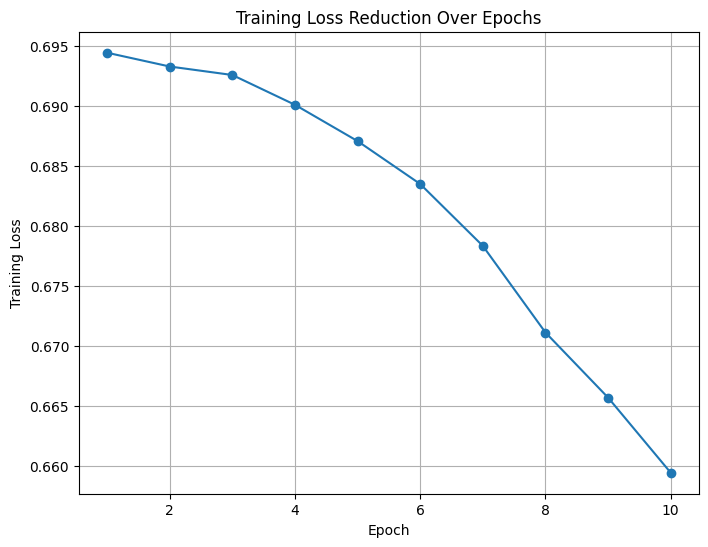

In [ ]:
from transformers import BertTokenizerFast
import matplotlib.pyplot as plt
from transformers import get_scheduler
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

num_epochs = 10
learning_rate = 1e-5
max_length=128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Attempting to improve training accuracy with data augmentation.
# train_dataset = WiCDataset([augment_example(example) for example in dataset["train"]], tokenizer)
# val_dataset = WiCDataset(dataset['validation'], tokenizer)
train_dataset = WiCDataset(dataset['train'], tokenizer, max_length)
val_dataset = WiCDataset(dataset['validation'], tokenizer, max_length)

# Testing a batch size increase.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

from transformers import AutoModel
bert_model = AutoModel.from_pretrained('bert-base-uncased')
model = WiCClassifier(bert_model)
model = model.to(device)

from peft import LoraConfig, get_peft_model, TaskType
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
    "bert.encoder.layer.4.attention.self.query",
    "bert.encoder.layer.4.attention.self.value",
    "bert.encoder.layer.5.attention.self.query",
    "bert.encoder.layer.5.attention.self.value",
    "bert.encoder.layer.6.attention.self.query",
    "bert.encoder.layer.6.attention.self.value",
    "bert.encoder.layer.8.attention.self.query",
    "bert.encoder.layer.8.attention.self.value",
    "bert.encoder.layer.9.attention.self.query",
    "bert.encoder.layer.9.attention.self.value",
    "bert.encoder.layer.10.attention.self.query",
    "bert.encoder.layer.10.attention.self.value",
    "bert.encoder.layer.11.attention.self.query",
    "bert.encoder.layer.11.attention.self.value",
    "classifier.0"
    ]
)

model = get_peft_model(model, lora_config)

llrd_params = [
    {"params": model.bert.embeddings.parameters(), "lr": 5e-6},
    {"params": model.bert.encoder.layer[:6].parameters(), "lr": 8e-6},
    {"params": model.bert.encoder.layer[6:9].parameters(), "lr": 1.8e-5},
    {"params": model.bert.encoder.layer[9:].parameters(), "lr": 2.5e-5},
    {"params": model.classifier.parameters(), "lr": 3e-5},
]

optimizer = torch.optim.AdamW(llrd_params, lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

accumulation_steps = 4

train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    progress_bar = tqdm(train_loader)
    for i, batch in enumerate(progress_bar):
        input_ids1 = batch['input_ids1'].to(device)
        input_ids2 = batch['input_ids2'].to(device)
        attention_mask1 = batch['attention_mask1'].to(device)
        attention_mask2 = batch['attention_mask2'].to(device)
        target_mask1 = batch['target_mask1'].to(device)
        target_mask2 = batch['target_mask2'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids1=input_ids1,
                        attention_mask1=attention_mask1,
                        input_ids2=input_ids2,
                        attention_mask2=attention_mask2,
                        target_mask1=target_mask1,
                        target_mask2=target_mask2)

        loss = criterion(outputs, labels)
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
          optimizer.step()
          scheduler.step()
          optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.set_postfix({f"Loss": loss.item()})


    avg_epoch_loss = total_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)


    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:

            input_ids1 = batch['input_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            target_mask1 = batch['target_mask1'].to(device)
            target_mask2 = batch['target_mask2'].to(device)
            labels = batch['label'].to(device)


            outputs = model(input_ids1=input_ids1,
                        attention_mask1=attention_mask1,
                        input_ids2=input_ids2,
                        attention_mask2=attention_mask2,
                        target_mask1=target_mask1,
                        target_mask2=target_mask2)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{num_epochs} done!")
    print(f"Average training loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Reduction Over Epochs")
plt.grid(True)
plt.show()


Checking model performance on test dataset.

In [ ]:
test_dataset = WiCDataset(dataset['test'], tokenizer, max_length)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            input_ids1 = batch['input_ids1'].to(device)
            input_ids2 = batch['input_ids2'].to(device)
            attention_mask1 = batch['attention_mask1'].to(device)
            attention_mask2 = batch['attention_mask2'].to(device)
            target_mask1 = batch['target_mask1'].to(device)
            target_mask2 = batch['target_mask2'].to(device)
            labels = batch['label'].to(device)


            outputs = model(
                input_ids1=input_ids1,
                attention_mask1=attention_mask1,
                input_ids2=input_ids2,
                attention_mask2=attention_mask2,
                target_mask1=target_mask1,
                target_mask2=target_mask2
            )

            _, predicted = torch.max(outputs.data, 1)


            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    test_accuracy = correct / total
    print(f"\nTest Accuracy: {test_accuracy:.4f}")

    return all_predictions, all_labels


test_predictions, test_labels = evaluate_model(model, test_loader, device)

Testing: 100%|██████████| 22/22 [00:11<00:00,  1.88it/s]


Test Accuracy: 0.5521


# Submission

Congratulations! You finished the assignment & you're ready to submit your work. Please follow the instructions:

1. Check and review your answers. Make sure all of the cell outputs are what you want.
2. Select File > Save.
3. **Fill your information** & run the cell bellow.
4. Run **Make Submission** cell, It may take several minutes and it may ask you for your credential.
5. Run **Download Submission** cell to obtain your submission as a zip file.
6. Grab the downloaded file (`dl_asg01__xx__xx.zip`) and hand it over.

## Fill your information (Run the cell)

In [ ]:
#@title Enter your information & "RUN the cell!!" { run: "auto" }
student_id = "24073905" #@param {type:"string"}
student_name = "Ian Rodríguez" #@param {type:"string"}

print("your student id:", student_id)
print("your name:", student_name)


from pathlib import Path

ASSIGNMENT_PATH = Path('asg01')
ASSIGNMENT_PATH.mkdir(parents=True, exist_ok=True)

your student id: 24073905
your name: Ian Rodríguez


## Make Submission (Run the cell)

In [ ]:
#@title Make submission
! pip install -U --quiet PyDrive > /dev/null
! pip install -U --quiet jdatetime > /dev/null
! apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc > /dev/null

import os
import time
import yaml
import json
import jdatetime

from google.colab import files
from IPython.display import Javascript
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

asg_name = 'WiC_Finetuning'
script_save = '''
require(["base/js/namespace"],function(Jupyter) {
    Jupyter.notebook.save_checkpoint();
});
'''

submission_file_name = 'dl_asg01__%s__%s.zip'%(student_id, student_name.lower().replace(' ',  '_'))

sub_info = {
    'student_id': student_id,
    'student_name': student_name,
    'dateime': str(jdatetime.date.today()),
    'asg_name': asg_name
}
json.dump(sub_info, open('info.json', 'w'))

Javascript(script_save)

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
file_id = drive.ListFile({'q':"title='%s.ipynb'"%asg_name}).GetList()[0]['id']
downloaded = drive.CreateFile({'id': file_id})
downloaded.GetContentFile('%s.ipynb'%asg_name)

! jupyter nbconvert --to script "$asg_name".ipynb > /dev/null
! jupyter nbconvert --to pdf "$asg_name".ipynb > /dev/null

! zip "$submission_file_name" "$asg_name".ipynb "$asg_name".html "$asg_name".txt info.json > /dev/null

print("##########################################")
print("Done! Submisson created, Please download using the bellow cell!")

[NbConvertApp] Converting notebook WiC_Finetuning.ipynb to script
[NbConvertApp] Writing 26343 bytes to WiC_Finetuning.txt
[NbConvertApp] Converting notebook WiC_Finetuning.ipynb to pdf
[NbConvertApp] Support files will be in WiC_Finetuning_files/
[NbConvertApp] Making directory ./WiC_Finetuning_files
[NbConvertApp] Writing 130210 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 151483 bytes to WiC_Finetuning.pdf
##########################################
Done! Submisson created, Please download using the bellow cell!


In [ ]:
drive.ListFile({'q':"title='%s.ipynb'"%asg_name}).GetList()[0]['id']

'1BiDjzxO69_PQU-UIUgMULtiMmY2vIaY-'

In [ ]:
files.download(submission_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>